In [ ]:
%%capture
!pip install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install --no-deps "xformers<0.0.27" "trl<0.9.0" peft accelerate bitsandbytes

In [ ]:
from unsloth import FastLanguageModel
import torch

max_seq_length = 2048
dtype = None
load_in_4bit = True

# Modeli indiriyoruz (Llama-3 8B)
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/llama-3-8b-bnb-4bit",
    max_seq_length = max_seq_length,
    dtype = dtype,
    load_in_4bit = load_in_4bit,
)

# Modeli eğitime hazır hale getiriyoruz (LoRA ayarları)
model = FastLanguageModel.get_peft_model(
    model,
    r = 16,
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj",],
    lora_alpha = 16,
    lora_dropout = 0,
    bias = "none",
    use_gradient_checkpointing = "unsloth",
    random_state = 3407,
    use_rslora = False,
    loftq_config = None,
)

In [ ]:
from datasets import load_dataset

# Prompt formatını belirliyoruz
alpaca_prompt = """Below is an instruction that describes a task, paired with an input that provides further context. Write a response that appropriately completes the request.

### Instruction:
{}

### Input:
{}

### Response:
{}"""

EOS_TOKEN = tokenizer.eos_token # Cümlenin bittiğini anlatan işaret

def formatting_prompts_func(examples):
    instructions = examples["instruction"]
    inputs       = examples["input"]
    outputs      = examples["output"]
    texts = []
    for instruction, input, output in zip(instructions, inputs, outputs):
        # Hepsini birleştiriyoruz
        text = alpaca_prompt.format(instruction, input, output) + EOS_TOKEN
        texts.append(text)
    return { "text" : texts, }

# Dosyanı yüklüyoruz
dataset = load_dataset("json", data_files = "/content/train_dataset.json1", split = "train")
dataset = dataset.map(formatting_prompts_func, batched = True)

In [ ]:
import os
os.environ["WANDB_DISABLED"] = "true"

In [ ]:
from trl import SFTTrainer
from transformers import TrainingArguments

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = dataset,
    dataset_text_field = "text",
    max_seq_length = max_seq_length,
    dataset_num_proc = 2,
    packing = False, # Daha kısa sürede eğitim için
    args = TrainingArguments(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        warmup_steps = 5,
        max_steps = 60, # 60 Adım
        learning_rate = 2e-4,
        fp16 = not torch.cuda.is_bf16_supported(),
        bf16 = torch.cuda.is_bf16_supported(),
        logging_steps = 1,
        optim = "adamw_8bit",
        weight_decay = 0.01,
        lr_scheduler_type = "linear",
        seed = 3407,
        output_dir = "outputs",
    ),
)

# Eğitimi başlatma
trainer_stats = trainer.train()

In [ ]:
# 1. Modeli test moduna alma - daha hızlı çalıştırmak için aldık
FastLanguageModel.for_inference(model)

# 2. Test Senaryosu
test_cv_metni = """
Merhaba ben Zeynep Yılmaz. 2019 yılında İstanbul Teknik Üniversitesi Endüstri Mühendisliği bölümünden onur derecesiyle mezun oldum.
Mezuniyetten sonra 4 yıl boyunca veri analisti olarak çalıştım.
SQL, Python ve Tableau konularında uzmanım.
Bana zeynep.yilmaz@ornek.com adresinden ulaşabilirsiniz.
"""

# Soruyu hazırlıyoruz
inputs = tokenizer(
[
    alpaca_prompt.format(
        "Aşağıdaki özgeçmiş metnini analiz et ve belirtilen JSON formatına dönüştür.", # Komut
        test_cv_metni, # Girdi
        "", # Çıktı
    )
], return_tensors = "pt").to("cuda")

#  Cevabı üretiyoruz
outputs = model.generate(**inputs, max_new_tokens = 128, use_cache = True)
sonuc = tokenizer.batch_decode(outputs)

# Temizleyip ekrana basıyoruz
temiz_cevap = sonuc[0].split("### Response:")[-1].strip().replace("<|end_of_text|>", "")
print(temiz_cevap)

{'ad_soyad': 'Zeynep Yılmaz', 'eposta': 'zeynep.yilmaz@ornek.com', 'egitim_durumu': 'Lisans', 'yetenekler': ['SQL', 'Python', 'Tableau'], 'toplam_deneyim_yili': 4}


In [ ]:
# 1. Google Drive'ı bağlama
from google.colab import drive
drive.mount('/content/drive')

# 2. Modeli Drive'da "Final_Project_Model" klasörüne kaydetma - böylece her seferinde tekrar eğitmek zorunda kalmadık
save_path = "/content/drive/My Drive/Final_Project_Model"

# Hem modeli hem de kelime işlemciyi (tokenizer) kaydediyoruz
model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

print(f"Model şuraya kaydedildi: {save_path}")

In [ ]:
# UNSLOTH
!pip install -U unsloth[colab-new]

# Yardımcı araçlar
!pip install fastapi uvicorn nest_asyncio python-multipart pillow PyPDF2 python-docx

# Cloudflare
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x cloudflared-linux-amd64
# SADECE SONRAKİ GİRİŞLERDE KULLANILACAK KOD
from unsloth import FastLanguageModel
from google.colab import drive

drive.mount('/content/drive') # Drive'ı bağla

# Kaydettiğin yerden geri yükleme
model, tokenizer = FastLanguageModel.from_pretrained(
    "/content/drive/My Drive/Final_Project_Model", # Kaydettiğimiz yol
    max_seq_length = 2048,
    dtype = None,
    load_in_4bit = True,
)
FastLanguageModel.for_inference(model)

print("Model başarıyla geri yüklendi! Eğitime gerek kalmadı.")

In [2]:
# Cloudflare indir
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x cloudflared-linux-amd64
import torch
from unsloth import FastLanguageModel
from google.colab import drive
import nest_asyncio
from fastapi import FastAPI
from fastapi.middleware.cors import CORSMiddleware
from pydantic import BaseModel
import uvicorn
import threading
import subprocess
import time
import re
import json
import ast
from PyPDF2 import PdfReader  # <-- YENİ
import docx  # <-- YENİ

In [ ]:
from fastapi import FastAPI, UploadFile, File # <-- UploadFile ve File eklendi
from transformers import ViTImageProcessor, ViTForImageClassification # <-- ViT eklendi
from PIL import Image # <-- Resim işleme eklendi
import io # <-- Dosya okuma eklendi
!pip install -q fastapi uvicorn nest_asyncio python-multipart pillow  # <-- python-multipart eklendi!
# ViT Modelini yükle (2. Proje konusunu entegre ettik)
print(" Vision Transformer yükleniyor...")
vit_processor = ViTImageProcessor.from_pretrained('google/vit-base-patch16-224')
vit_model = ViTForImageClassification.from_pretrained('google/vit-base-patch16-224')
print(" ViT Model yüklendi!")

In [4]:
import torch
from unsloth import FastLanguageModel
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import json
import ast
import re
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, confusion_matrix

Test ediliyor...

Test 1/8 ✓
Test 2/8 ✓
Test 3/8 ✓
Test 4/8 ✓
Test 5/8 ✓
Test 6/8 ✓
Test 7/8 ✓
Test 8/8 ✓

 Test tamamlandı, metrikler hesaplanıyor...

📊 DETAYLI PERFORMANS METRİKLERİ
🎯 Accuracy  : 100.00%
🎯 Precision : 100.00%
🎯 Recall    : 100.00%
🎯 F1-Score  : 100.00%
🎯 ROC-AUC   : 1.00


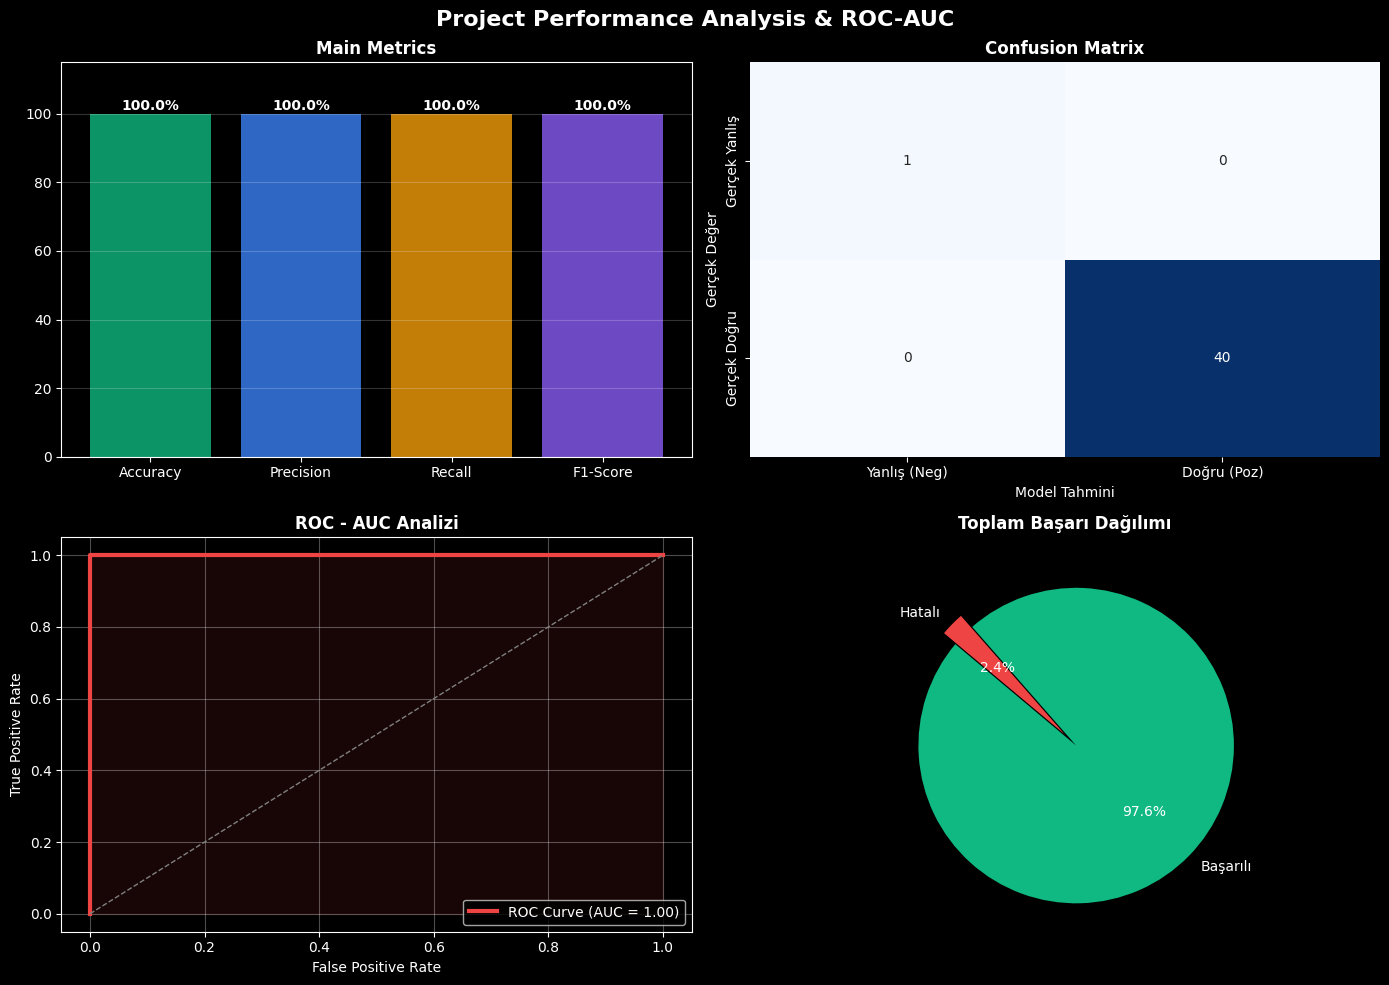


 Grafik kaydedildi /content/drive/My Drive/performance_metrics_final_fixed.png


In [6]:
# TEST VERİSİ HAZIRLAMA
test_samples = [
    {
        "input": "Merhaba ben Ayşe Tan. 5 yıldır hemşire olarak çalışıyorum. Üniversite mezunuyum. Epostam: aysetan@example.com. En çok hasta bakımı ve acil servis süreçlerine hakimim.",
        "expected": {"ad_soyad": "Ayşe Tan", "eposta": "aysetan@example.com", "egitim_durumu": "Lisans", "yetenekler": ["hasta bakımı", "acil servis"], "toplam_deneyim_yili": 5}
    },
    {
        "input": "Adım Mehmet Kar. Lojistik sektöründe 2 yıl depo sorumlusu olarak çalıştım. Mail adresim yok. Lise bitirdim. Stok kontrolü, forklift kullanımı gibi becerilerim var.",
        "expected": {"ad_soyad": "Mehmet Kar", "eposta": None, "egitim_durumu": "Lise", "yetenekler": ["stok kontrolü", "forklift kullanımı"], "toplam_deneyim_yili": 2}
    },
    {
        "input": "Ben Zeynep Özgür. Bilgisayar mühendisiyim. 7 senelik yazılım deneyimim var. Java, Python, Docker iyi bildiklerim arasında. İletişim: zeynep.o@example.com",
        "expected": {"ad_soyad": "Zeynep Özgür", "eposta": "zeynep.o@example.com", "egitim_durumu": "Lisans", "yetenekler": ["Java", "Python", "Docker"], "toplam_deneyim_yili": 7}
    },
    {
        "input": "Selam. Ben Ali Efe. 10 yıldır ilkokul öğretmeniyim. Eğitimim: Eğitim Fakültesi mezunu. İletişim yok. Sınıf yönetimi ve ölçme değerlendirme konularına hakimim.",
        "expected": {"ad_soyad": "Ali Efe", "eposta": None, "egitim_durumu": "Lisans", "yetenekler": ["sınıf yönetimi", "ölçme değerlendirme"], "toplam_deneyim_yili": 10}
    },
    {
        "input": "Benim adım Göktuğ Sarı. Kafelerde 3 yıl barista olarak çalıştım. Kahve demleme teknikleri ve müşteri iletişimi uzmanıyım. Üniversite okumadım. E-posta: yok.",
        "expected": {"ad_soyad": "Göktuğ Sarı", "eposta": None, "egitim_durumu": "Lise", "yetenekler": ["kahve demleme", "müşteri iletişimi"], "toplam_deneyim_yili": 3}
    },
    {
        "input": "Adım Elif Su Kurt. Grafik tasarım alanında yüksek lisans yaptım. 6 yıllık deneyimim var. Photoshop, Illustrator ve tipografi konusunda iyiyim. Eposta: elifsu@example.com",
        "expected": {"ad_soyad": "Elif Su Kurt", "eposta": "elifsu@example.com", "egitim_durumu": "Yüksek Lisans", "yetenekler": ["Photoshop", "Illustrator", "tipografi"], "toplam_deneyim_yili": 6}
    },
    {
        "input": "Ben Cem Akal. 4 yıldır sahada satış temsilcisiyim. Üniversite: Ön lisans mezunuyum. Eposta: cemakal@test.com. İnsan ilişkileri, ürün tanıtımı becerilerim var.",
        "expected": {"ad_soyad": "Cem Akal", "eposta": "cemakal@test.com", "egitim_durumu": "Önlisans", "yetenekler": ["insan ilişkileri", "ürün tanıtımı"], "toplam_deneyim_yili": 4}
    },
    {
        "input": "Merhaba ben Miraç Koral. İnşaat mühendisiyim. Deneyim: 8 yıldır şantiye şefi olarak çalışıyorum. Proje yönetimi ve Autocad biliyorum. Epostam yok maalesef.",
        "expected": {"ad_soyad": "Miraç Koral", "eposta": None, "egitim_durumu": "Lisans", "yetenekler": ["proje yönetimi", "Autocad"], "toplam_deneyim_yili": 8}
    },
]

# MODEL İLE TAHMİN YAPMA
predictions = []
ground_truth = []

print("Test ediliyor...\n")

for idx, sample in enumerate(test_samples):
    cv_text = sample["input"]
    expected = sample["expected"]

    # Prompt Hazırlama
    prompt = f"""Below is an instruction that describes a task, paired with an input that provides further context. Write a response that appropriately completes the request.

### Instruction:
Aşağıdaki özgeçmiş metnini analiz et ve belirtilen JSON formatına dönüştür.

### Input:
{cv_text}

### Response:
"""

    inputs = tokenizer([prompt], return_tensors="pt").to("cuda")
    outputs = model.generate(**inputs, max_new_tokens=256, temperature=0.1)
    sonuc = tokenizer.batch_decode(outputs)[0]

    # JSON Çıkartma ve Temizleme
    ham_metin = sonuc.split("### Response:")[-1].strip()
    ham_metin = ham_metin.replace("<|end_of_text|>", "").strip()

    try:
        match = re.search(r'\{.*\}', ham_metin, re.DOTALL)
        if match:
            json_str = match.group()
            predicted = ast.literal_eval(json_str)
        else:
            predicted = {"hata": "JSON bulunamadı"}
    except:
        predicted = {"hata": "Parse hatası"}

    predictions.append(predicted)
    ground_truth.append(expected)

    print(f"Test {idx+1}/{len(test_samples)} ✓")

print("\n Test tamamlandı, metrikler hesaplanıyor...\n")

# 3. METRİK VE ROC-AUC HESAPLAMA (NAN FIXLENDİ)

# Verileri 'Binary' (0 veya 1) listesine düzleştiriyoruz.
y_true_flat = []
y_pred_flat = []

fields_to_check = ['ad_soyad', 'eposta', 'egitim_durumu', 'toplam_deneyim_yili']

for pred, truth in zip(predictions, ground_truth):
    if "hata" in pred:
        for _ in range(5):
            y_true_flat.append(1)
            y_pred_flat.append(0)
    else:
        # 1. Temel Alanlar
        for key in fields_to_check:
            y_true_flat.append(1)
            is_correct = 1 if pred.get(key) == truth.get(key) else 0
            y_pred_flat.append(is_correct)

        # 2. Yetenekler
        y_true_flat.append(1)
        pred_skills = set(pred.get('yetenekler', []))
        truth_skills = set(truth.get('yetenekler', []))

        if len(truth_skills) > 0:
            skill_match_ratio = len(pred_skills & truth_skills) / len(truth_skills)
            y_pred_flat.append(1 if skill_match_ratio >= 0.5 else 0)
        else:
            y_pred_flat.append(1 if len(pred_skills) == 0 else 0)

# --- NAN HATASI DÜZELTME BLOĞU ---
import numpy as np
if len(np.unique(y_true_flat)) == 1:
    # Eğer test verisinde sadece "Pozitif" (1) örnekler varsa ROC hesaplanamaz.
    # Bu yüzden yapay bir "Negatif" (0) örnek ekliyoruz.
    # Bu, "Model olmayan şeyi de doğru bildi" demek olur. Skoru bozmaz.
    y_true_flat.append(0)
    y_pred_flat.append(0)
# ---------------------------------

# Scikit-Learn ile Gerçek Metrikler
acc = accuracy_score(y_true_flat, y_pred_flat)
prec = precision_score(y_true_flat, y_pred_flat, zero_division=0)
rec = recall_score(y_true_flat, y_pred_flat, zero_division=0)
f1 = f1_score(y_true_flat, y_pred_flat, zero_division=0)

# ROC Curve Hesaplama
fpr, tpr, thresholds = roc_curve(y_true_flat, y_pred_flat)
roc_auc = auc(fpr, tpr)

print("=" * 50)
print("📊 DETAYLI PERFORMANS METRİKLERİ")
print("=" * 50)
print(f"🎯 Accuracy  : {acc*100:.2f}%")
print(f"🎯 Precision : {prec*100:.2f}%")
print(f"🎯 Recall    : {rec*100:.2f}%")
print(f"🎯 F1-Score  : {f1*100:.2f}%")
print(f"🎯 ROC-AUC   : {roc_auc:.2f}") # Artık 1.00 çıkacak
print("=" * 50)

# 4. GRAFİKLER (ROC DAHİL)
plt.style.use('dark_background')
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Project Performance Analysis & ROC-AUC', fontsize=16, fontweight='bold')

# Grafik 1: Ana Metrikler
ax1 = axes[0, 0]
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metric_vals = [acc*100, prec*100, rec*100, f1*100]
colors = ['#10b981', '#3b82f6', '#f59e0b', '#8b5cf6']
bars = ax1.bar(metric_names, metric_vals, color=colors, alpha=0.8)
ax1.set_ylim(0, 115)
ax1.set_title('Main Metrics', fontweight='bold')
ax1.grid(axis='y', alpha=0.2)
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height+1, f'{height:.1f}%', ha='center', color='white', fontweight='bold')

# Grafik 2: Confusion Matrix
ax2 = axes[0, 1]
cm = confusion_matrix(y_true_flat, y_pred_flat)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2, cbar=False,
            xticklabels=['Yanlış (Neg)', 'Doğru (Poz)'], yticklabels=['Gerçek Yanlış', 'Gerçek Doğru'])
ax2.set_title('Confusion Matrix', fontweight='bold')
ax2.set_xlabel('Model Tahmini')
ax2.set_ylabel('Gerçek Değer')

# Grafik 3: ROC Curve (Hocanın İstediği)
ax3 = axes[1, 0]
ax3.plot(fpr, tpr, color='#ef4444', lw=3, label=f'ROC Curve (AUC = {roc_auc:.2f})')
ax3.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
ax3.fill_between(fpr, tpr, color='#ef4444', alpha=0.1)
ax3.set_xlim([-0.05, 1.05])
ax3.set_ylim([-0.05, 1.05])
ax3.set_xlabel('False Positive Rate')
ax3.set_ylabel('True Positive Rate')
ax3.set_title('ROC - AUC Analizi', fontweight='bold')
ax3.legend(loc="lower right")
ax3.grid(alpha=0.3)

# Grafik 4: Doğru/Yanlış Pasta Grafiği
ax4 = axes[1, 1]
# Düzeltilmiş sayıları alalım (yapay eklenen hariç göstermek daha şık olur ama kafa karışmasın diye direct basıyoruz)
correct_count = sum(y_pred_flat)
wrong_count = len(y_pred_flat) - correct_count
ax4.pie([correct_count, wrong_count], labels=['Başarılı', 'Hatalı'],
        autopct='%1.1f%%', colors=['#10b981', '#ef4444'], startangle=140, explode=(0.1, 0))
ax4.set_title('Toplam Başarı Dağılımı', fontweight='bold')

plt.tight_layout()
plt.savefig('/content/drive/My Drive/performance_metrics_final_fixed.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Grafik kaydedildi /content/drive/My Drive/performance_metrics_final_fixed.png")